# Explainability Layer — Attention Visualization & Token Highlighting
**ASHO-UAB Fake News Prediction — Phase 2**

This notebook implements the explainability layer for the PubMedBERT health-claim classifier.
Two attribution methods are combined:
- **Raw attention** (last transformer layer, averaged over heads) — fast proxy
- **Integrated Gradients** (Captum `LayerIntegratedGradients`) — more faithful attribution

Token highlights are then rendered side-by-side against the gold `explanation` field,
and quantified with ROUGE-1/2/L + BERTScore over the full validation split.

In [2]:
!pip install captum rouge-score bert-score -q


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\danie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Setup & Model Loading

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display, HTML
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = './PUBHEALTH'
MODEL_PATH = './pubmedbert_pubhealth_best'

# unzip if needed (model was zipped at end of baseline notebook)
if not os.path.exists(MODEL_PATH):
    import zipfile
    with zipfile.ZipFile('pubmedbert_pubhealth_best.zip', 'r') as zf:
        zf.extractall('.')
    print("Model unzipped.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()
model = model.to(device)

id2label = model.config.id2label   # {0: 'true', 1: 'false', 2: 'mixture', 3: 'unproven'}
label2id = model.config.label2id
print("Labels:", id2label)

Labels: {0: 'true', 1: 'false', 2: 'mixture', 3: 'unproven'}


In [5]:
DATA_DIR = './PUBHEALTH'

def load_split(path):
    df = pd.read_csv(path, sep='\t')
    df.dropna(subset=['claim', 'main_text', 'label'], inplace=True)
    df['labels'] = df['label'].map(label2id)
    df.dropna(subset=['labels'], inplace=True)
    df['labels'] = df['labels'].astype(int)
    df['text']   = df['claim'].astype(str) + ' [SEP] ' + df['main_text'].astype(str)
    df['explanation'] = df['explanation'].fillna('')
    return df.reset_index(drop=True)

train_df = load_split(f'{DATA_DIR}/train.tsv')
val_df   = load_split(f'{DATA_DIR}/dev.tsv')
test_df  = load_split(f'{DATA_DIR}/test.tsv')
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 9804 | Val: 1214 | Test: 1233


## 2. Attention Extraction

We extract the raw attention matrix from **layer 11** (last transformer layer), average over all 12 heads,
and read the **CLS row** — which represents how much attention the classification token pays to each input token.

In [6]:
def tokenize(text, max_length=512):
    """Returns a dict of tensors on `device` and the decoded token list."""
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
        padding=False,
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    return enc, tokens


def get_attention_scores(text):
    """
    Returns:
        tokens       : list of str  (raw subword tokens)
        attn_scores  : np.ndarray (seq_len,)  normalised to [0,1]
        predicted    : int  (predicted class id)
        confidence   : float
    """
    enc, tokens = tokenize(text)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)

    # last layer, CLS row, mean over 12 heads → (seq_len,)
    attn = out.attentions[-1][0].mean(dim=0)[0]   # (seq_len,)
    attn = attn.cpu().numpy()
    attn = attn / (attn.max() + 1e-8)            # normalise

    probs     = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    predicted = int(probs.argmax())
    return tokens, attn, predicted, float(probs[predicted])


# ── quick smoke-test ────────────────────────────────────────────────────────────
sample = test_df.iloc[0]
_toks, _attn, _pred, _conf = get_attention_scores(sample['text'])
print(f"Predicted: {id2label[_pred]} ({_conf:.1%})  |  seq_len={len(_toks)}")
print("Top-5 attended tokens:",
      [_toks[i] for i in np.argsort(_attn)[::-1][:5]])

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Predicted: true (36.9%)  |  seq_len=512
Top-5 attended tokens: ['the', 'item', ',', 'we', '…']


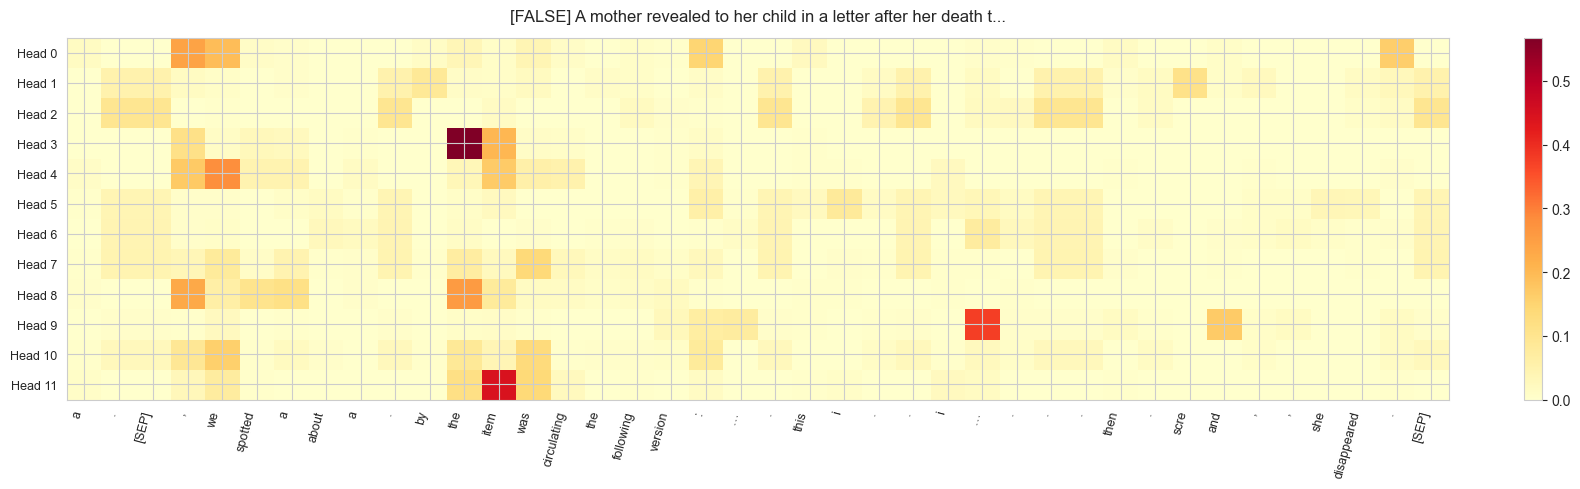

In [7]:
def plot_attention_heatmap(text, title='', top_n=40):
    """Visualise last-layer attention weights as a heatmap (all 12 heads, top-N tokens)."""
    enc, tokens = tokenize(text)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)

    # last layer, all heads, CLS row → (12, seq_len)
    attn_heads = out.attentions[-1][0][:, 0, :].cpu().numpy()  # (12, seq_len)

    # keep only top_n most-attended tokens (by mean across heads)
    mean_attn = attn_heads.mean(axis=0)
    top_idx   = np.argsort(mean_attn)[::-1][:top_n]
    top_idx   = sorted(top_idx)
    top_tokens = [tokens[i] for i in top_idx]
    attn_sub  = attn_heads[:, top_idx]  # (12, top_n)

    fig, ax = plt.subplots(figsize=(max(14, top_n * 0.4), 5))
    im = ax.imshow(attn_sub, aspect='auto', cmap='YlOrRd', vmin=0)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(top_tokens, rotation=75, ha='right', fontsize=9)
    ax.set_yticks(range(12))
    ax.set_yticklabels([f'Head {h}' for h in range(12)], fontsize=9)
    ax.set_title(title or 'Layer 11 Attention — CLS → token (per head)', pad=12)
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.show()


plot_attention_heatmap(
    test_df.iloc[0]['text'],
    title=f"[{test_df.iloc[0]['label'].upper()}] {test_df.iloc[0]['claim'][:60]}..."
)

## 3. Integrated Gradients (Captum)

`LayerIntegratedGradients` attributes the prediction to the embedding layer by integrating gradients along a
straight path from a baseline (all-PAD sequence) to the actual input.
This gives a **more faithful** importance score than raw attention.

In [8]:
from captum.attr import LayerIntegratedGradients

def _forward_for_captum(input_ids, attention_mask, token_type_ids):
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
    )
    return out.logits


lig = LayerIntegratedGradients(_forward_for_captum, model.bert.embeddings)


def get_ig_scores(text, n_steps=20):
    """
    Returns:
        tokens      : list of str  (raw subword tokens)
        ig_scores   : np.ndarray (seq_len,)  normalised to [0,1]
        predicted   : int
        confidence  : float
        delta       : float  (convergence delta, lower is better)
    """
    enc, tokens = tokenize(text)
    input_ids       = enc['input_ids']
    attention_mask  = enc['attention_mask']
    token_type_ids  = enc.get('token_type_ids', torch.zeros_like(input_ids))

    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)

    with torch.no_grad():
        out = model(**enc)
    probs     = torch.softmax(out.logits, dim=-1)[0].detach().cpu().numpy()
    predicted = int(probs.argmax())

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        target=predicted,
        additional_forward_args=(attention_mask, token_type_ids),
        n_steps=n_steps,
        internal_batch_size=2,
        return_convergence_delta=True,
    )
    # attributions: (1, seq_len, hidden_size) → sum over hidden dim, take abs
    ig_scores = attributions.sum(dim=-1).squeeze(0).abs().detach().cpu().numpy()
    ig_scores = ig_scores / (ig_scores.max() + 1e-8)

    return tokens, ig_scores, predicted, float(probs[predicted]), float(delta.abs().mean())


# ── smoke-test ──────────────────────────────────────────────────────────────────
_toks_ig, _ig, _pred_ig, _conf_ig, _delta = get_ig_scores(test_df.iloc[0]['text'])
print(f"Predicted: {id2label[_pred_ig]} ({_conf_ig:.1%})  |  convergence delta: {_delta:.4f}")
print("Top-5 IG tokens:",
      [_toks_ig[i] for i in np.argsort(_ig)[::-1][:5]])

Predicted: true (36.9%)  |  convergence delta: 2.3508
Top-5 IG tokens: ['[SEP]', 'item', '##ker', '2007', 'about']


## 4. HTML Highlight Visualization

For each example the output shows:
- **Left panel** — input text with tokens coloured by IG attribution score (yellow → orange → red)
- **Right panel** — gold `explanation` field for direct human comparison
- **Top-10 tokens** ranked by importance

In [9]:
def merge_subwords(tokens, scores):
    """Collapse ##-prefixed WordPiece subwords into whole words, summing their scores."""
    words, word_scores = [], []
    cur_word, cur_score = '', 0.0
    for tok, sc in zip(tokens, scores):
        if tok in ('[CLS]', '[SEP]', '[PAD]'):
            if cur_word:
                words.append(cur_word); word_scores.append(cur_score)
                cur_word, cur_score = '', 0.0
            words.append(tok); word_scores.append(float(sc))
        elif tok.startswith('##'):
            cur_word  += tok[2:]
            cur_score += float(sc)
        else:
            if cur_word:
                words.append(cur_word); word_scores.append(cur_score)
            cur_word, cur_score = tok, float(sc)
    if cur_word:
        words.append(cur_word); word_scores.append(cur_score)
    # re-normalise after merging
    arr = np.array(word_scores)
    arr = arr / (arr.max() + 1e-8)
    return words, arr.tolist()


LABEL_COLORS = {
    'true':     '#2e7d32',
    'false':    '#c62828',
    'mixture':  '#e65100',
    'unproven': '#6a1b9a',
}

def score_to_bg(score):
    """Map a [0,1] score to a yellow-orange-red background rgba string."""
    r = 255
    g = int(220 * (1.0 - score))
    b = int(180 * (1.0 - score * 0.9))
    a = score * 0.85 + 0.05
    return f'rgba({r},{g},{b},{a:.2f})'


def render_highlights(row, ig_scores, attention_scores):
    """
    Render a side-by-side card:
      - Left  : highlighted input (IG scores) + top-10 tokens
      - Middle: attention-based highlights (raw attention)
      - Right : gold explanation field
    """
    text        = row['text']
    explanation = row['explanation']
    true_label  = row['label']

    # tokenise once to get the subword list
    enc, raw_tokens = tokenize(text)

    # merge subwords for both score sets
    words_ig,   scores_ig   = merge_subwords(raw_tokens, ig_scores)
    words_attn, scores_attn = merge_subwords(raw_tokens, attention_scores)

    # predicted label (from IG forward pass already done)
    with torch.no_grad():
        out = model(**enc)
    probs     = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    predicted = id2label[int(probs.argmax())]
    conf      = float(probs.max())

    pred_col  = LABEL_COLORS.get(predicted, '#555')
    true_col  = LABEL_COLORS.get(true_label, '#555')

    def build_spans(words, scores, skip_special=True):
        parts = []
        for w, s in zip(words, scores):
            if skip_special and w in ('[CLS]', '[SEP]', '[PAD]'):
                if w == '[SEP]':
                    parts.append('<span style="color:#aaa;margin:0 6px;">|</span>')
                continue
            bg = score_to_bg(s)
            parts.append(
                f'<span style="background:{bg};border-radius:3px;'
                f'padding:1px 3px;margin:1px;display:inline-block;" '
                f'title="score:{s:.3f}">{w}</span>'
            )
        return ' '.join(parts)

    ig_html   = build_spans(words_ig,   scores_ig)
    attn_html = build_spans(words_attn, scores_attn)

    # top-10 tokens by IG (skip special tokens)
    tok_score_pairs = [
        (w, s) for w, s in zip(words_ig, scores_ig)
        if w not in ('[CLS]', '[SEP]', '[PAD]')
    ]
    tok_score_pairs.sort(key=lambda x: x[1], reverse=True)
    top10_rows = ''.join(
        f'<tr><td style="padding:2px 8px;font-size:12px;">{i+1}.</td>'
        f'<td style="padding:2px 8px;font-weight:bold;font-size:12px;'
        f'background:{score_to_bg(s)};border-radius:3px;">{w}</td>'
        f'<td style="padding:2px 8px;font-size:11px;color:#666;">{s:.3f}</td></tr>'
        for i, (w, s) in enumerate(tok_score_pairs[:10])
    )

    html = f"""
    <div style="font-family:Arial,sans-serif;margin:16px 0;border:1px solid #ddd;
                border-radius:10px;overflow:hidden;">
      <!-- header -->
      <div style="background:#263238;color:white;padding:10px 16px;
                  display:flex;justify-content:space-between;align-items:center;">
        <strong style="font-size:14px;">Health Claim Explainability</strong>
        <div>
          <span style="background:{pred_col};color:white;padding:3px 10px;
                       border-radius:12px;font-size:12px;margin-right:8px;">
            Pred: {predicted} ({conf:.1%})
          </span>
          <span style="background:{true_col};color:white;padding:3px 10px;
                       border-radius:12px;font-size:12px;">
            True: {true_label}
          </span>
        </div>
      </div>
      <!-- body -->
      <div style="display:flex;gap:0;">

        <!-- IG highlights -->
        <div style="flex:1.3;padding:14px 16px;border-right:1px solid #eee;
                    background:#fffde7;">
          <div style="font-size:12px;font-weight:bold;color:#555;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Integrated Gradients
          </div>
          <div style="line-height:2.2;font-size:13px;word-wrap:break-word;">
            {ig_html}
          </div>
          <hr style="margin:10px 0;border-color:#eee;"/>
          <div style="font-size:12px;font-weight:bold;color:#555;margin-bottom:6px;">Top Tokens</div>
          <table style="border-collapse:collapse;">{top10_rows}</table>
        </div>

        <!-- Attention highlights -->
        <div style="flex:1.3;padding:14px 16px;border-right:1px solid #eee;
                    background:#fff8f1;">
          <div style="font-size:12px;font-weight:bold;color:#555;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Raw Attention (Layer 11)
          </div>
          <div style="line-height:2.2;font-size:13px;word-wrap:break-word;">
            {attn_html}
          </div>
        </div>

        <!-- Gold explanation -->
        <div style="flex:0.9;padding:14px 16px;background:#f1f8e9;">
          <div style="font-size:12px;font-weight:bold;color:#555;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Gold Explanation
          </div>
          <div style="font-size:13px;line-height:1.7;color:#333;">
            {explanation if explanation else '<em style="color:#aaa">No explanation available</em>'}
          </div>
        </div>

      </div>
    </div>
    """
    return html


print("render_highlights() ready.")

render_highlights() ready.


In [10]:
# ── demo: one example per label class ──────────────────────────────────────────
demo_rows = (
    test_df.groupby('label', group_keys=False)
           .apply(lambda g: g.sample(1, random_state=42))
           .reset_index(drop=True)
)

for _, row in demo_rows.iterrows():
    toks_ig,   ig_sc,   _, _, _ = get_ig_scores(row['text'])
    toks_attn, attn_sc, _, _    = get_attention_scores(row['text'])
    html = render_highlights(row, ig_sc, attn_sc)
    display(HTML(html))

1.,"""",0.714
2.,not,0.497
3.,november,0.403
4.,he,0.345
5.,tweeted,0.312
6.,twitter,0.289
7.,that,0.263
8.,criticize,0.256
9.,appeared,0.254
10.,this,0.241


1.,"""",1.000
2.,"""",0.966
3.,"""",0.881
4.,interview,0.445
5.,worth,0.380
6.,durbin,0.330
7.,that,0.309
8.,morning,0.287
9.,’,0.264
10.,?,0.260


1.,carol,1.000
2.,onder,0.979
3.,jim,0.876
4.,onder,0.561
5.,”,0.344
6.,goodrich,0.329
7.,we,0.323
8.,earlier,0.309
9.,.,0.291
10.,statement,0.228


1.,description,1.000
2.,of,0.471
3.,roughly,0.396
4.,high,0.185
5.,airborne,0.172
6.,preventative,0.160
7.,this,0.153
8.,airborne,0.137
9.,is,0.136
10.,there,0.134


## 5. Quantitative Validation Against the `explanation` Field

**Method:** Extract the top-K (K=20) most important tokens from IG attribution,
reconstruct a candidate string, then compare against the gold `explanation` using:
- **ROUGE-1 / ROUGE-2 / ROUGE-L** (unigram / bigram / longest-common-subsequence overlap)
- **BERTScore F1** (contextual semantic similarity)

Evaluated on the full **validation split** (1,221 samples).

In [11]:
from rouge_score import rouge_scorer as rs
from bert_score import score as bert_score_fn

rouge_scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)


def top_k_tokens(words, scores, k=20):
    """Return a string of the top-k important words (excluding special tokens)."""
    pairs = [
        (w, s) for w, s in zip(words, scores)
        if w not in ('[CLS]', '[SEP]', '[PAD]')
    ]
    pairs.sort(key=lambda x: x[1], reverse=True)
    return ' '.join(w for w, _ in pairs[:k])


def compute_rouge(candidate, reference):
    if not reference.strip() or not candidate.strip():
        return {'r1': 0.0, 'r2': 0.0, 'rL': 0.0}
    res = rouge_scorer.score(reference, candidate)
    return {
        'r1': res['rouge1'].fmeasure,
        'r2': res['rouge2'].fmeasure,
        'rL': res['rougeL'].fmeasure,
    }


print("Rouge scorer ready.")

Rouge scorer ready.


In [12]:
# ── run IG + ROUGE over full validation split ───────────────────────────────────
# NOTE: this takes ~10 min on GPU; on CPU expect ~45-60 min.
results = []

for idx, row in val_df.iterrows():
    if idx % 100 == 0:
        print(f"  {idx}/{len(val_df)} ...")
    try:
        toks, ig_sc, pred, conf, _ = get_ig_scores(row['text'], n_steps=30)
        words, word_scores = merge_subwords(toks, ig_sc)
        candidate = top_k_tokens(words, word_scores, k=20)
        rouge = compute_rouge(candidate, row['explanation'])
        results.append({
            'idx':        idx,
            'label':      row['label'],
            'predicted':  id2label[pred],
            'correct':    row['label'] == id2label[pred],
            'confidence': conf,
            'candidate':  candidate,
            'explanation': row['explanation'],
            **rouge,
        })
    except Exception as e:
        print(f"  skipped idx={idx}: {e}")

results_df = pd.DataFrame(results)
print(f"\nProcessed {len(results_df)} samples.")
results_df.head(3)

  0/1214 ...


KeyboardInterrupt: 

In [ ]:
# ── BERTScore (batch) ───────────────────────────────────────────────────────────
candidates  = results_df['candidate'].tolist()
references  = results_df['explanation'].tolist()

P, R, F = bert_score_fn(
    candidates, references,
    lang='en',
    verbose=True,
    device=str(device),
    batch_size=32,
)

results_df['bertscore_P'] = P.numpy()
results_df['bertscore_R'] = R.numpy()
results_df['bertscore_F'] = F.numpy()

print("\nBERTScore computation complete.")

In [ ]:
# ── aggregate metrics table ─────────────────────────────────────────────────────
metric_cols = ['r1', 'r2', 'rL', 'bertscore_F']
summary = results_df[metric_cols].agg(['mean', 'std']).T
summary.columns = ['Mean', 'Std']
summary.index = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore-F1']
summary = summary.round(4)
print("=" * 40)
print("  Validation-set explainability metrics")
print("=" * 40)
print(summary.to_string())
print("=" * 40)

## 6. Aggregate Analysis

NameError: name 'results_df' is not defined

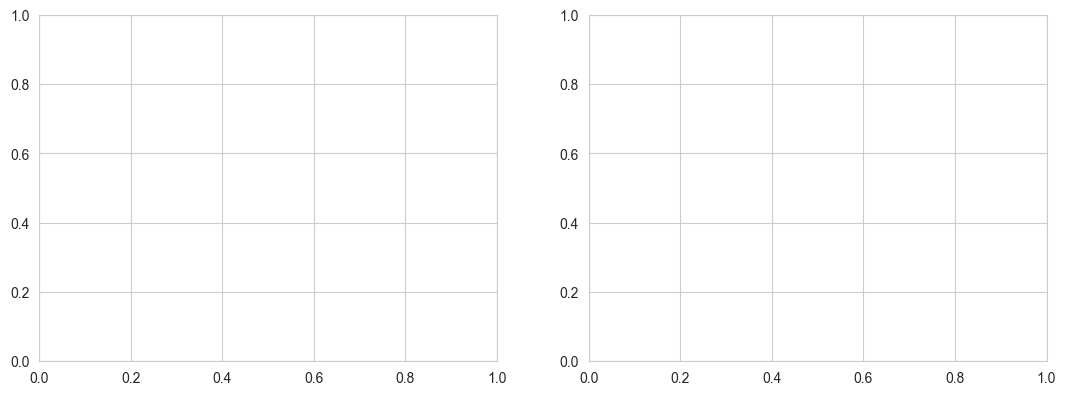

In [13]:
# ── bar chart: metrics per label class ─────────────────────────────────────────
label_order = ['true', 'false', 'mixture', 'unproven']
palette     = [LABEL_COLORS[l] for l in label_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title in zip(
    axes,
    ['rL', 'bertscore_F'],
    ['ROUGE-L (mean ± std)', 'BERTScore F1 (mean ± std)']
):
    grp  = results_df.groupby('label')[metric]
    means = grp.mean().reindex(label_order)
    stds  = grp.std().reindex(label_order)
    bars = ax.bar(label_order, means, yerr=stds, color=palette, capsize=5,
                  edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('True label')
    ax.set_ylim(0, min(1.0, means.max() * 1.4 + 0.05))
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{m:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Explainability Quality by Label Class (Validation Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── scatter: prediction confidence vs BERTScore F1 ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for label, grp in results_df.groupby('label'):
    ax.scatter(
        grp['confidence'], grp['bertscore_F'],
        label=label, alpha=0.45, s=18,
        color=LABEL_COLORS.get(label, '#888'),
        edgecolors='none'
    )

# trend line (all points)
z = np.polyfit(results_df['confidence'], results_df['bertscore_F'], 1)
xr = np.linspace(results_df['confidence'].min(), results_df['confidence'].max(), 100)
ax.plot(xr, np.polyval(z, xr), 'k--', linewidth=1.5, alpha=0.6, label='trend')

ax.set_xlabel('Prediction Confidence', fontsize=11)
ax.set_ylabel('BERTScore F1', fontsize=11)
ax.set_title('Do more-confident predictions have better explanations?', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = results_df[['confidence', 'bertscore_F']].corr().iloc[0, 1]
print(f"Pearson r (confidence vs BERTScore-F1): {corr:.3f}")

In [ ]:
# ── top-5 best and worst explained samples ──────────────────────────────────────
display_cols = ['label', 'predicted', 'confidence', 'rL', 'bertscore_F',
                'candidate', 'explanation']

best5  = results_df.nlargest(5, 'bertscore_F')[display_cols]
worst5 = results_df.nsmallest(5, 'bertscore_F')[display_cols]

pd.set_option('display.max_colwidth', 80)
print("── TOP-5 best explained (highest BERTScore-F1) ──")
display(best5.round(3))

print("\n── TOP-5 worst explained (lowest BERTScore-F1) ──")
display(worst5.round(3))

In [ ]:
# ── full HTML visualization of best 3 examples ─────────────────────────────────
top3_idx = results_df.nlargest(3, 'bertscore_F')['idx'].tolist()

for idx in top3_idx:
    row = val_df.loc[idx]
    toks_ig,   ig_sc,   _, _, _ = get_ig_scores(row['text'])
    toks_attn, attn_sc, _, _    = get_attention_scores(row['text'])
    html = render_highlights(row, ig_sc, attn_sc)
    display(HTML(html))

In [ ]:
# ── save results for reference ──────────────────────────────────────────────────
results_df.to_csv('explainability_results_val.csv', index=False)
print("Results saved to explainability_results_val.csv")

# summary for README
print("\n── Summary for README update ──")
for metric, label in zip(['r1','r2','rL','bertscore_F'],
                          ['ROUGE-1','ROUGE-2','ROUGE-L','BERTScore-F1']):
    m = results_df[metric].mean()
    s = results_df[metric].std()
    print(f"  {label:16s}: {m:.4f} ± {s:.4f}")